# Hand-On Week 4: 

## Text Classification with TF-IDF

Before jumping to deep learning, let's see the **classical ML pipeline** in action.

### Key concept: Feature Engineering

In classical ML, the model never sees raw text. We first transform text into a **numeric feature vector**:

```
"Google buys DeepMind"  →  [0.0, 0.32, 0.0, 0.71, ...]   (TF-IDF vector)
                                                              ↑
                                          length = vocabulary size (e.g. 50,000)
```

**TF-IDF** (Term Frequency–Inverse Document Frequency) weights words by how distinctive they are:
- Common words like *"the"* get low weight
- Rare, informative words get high weight

In [1]:
import random
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Random Seed at file level
random_seed = 42

np.random.seed(random_seed)
random.seed(random_seed)

In [2]:
texts, labels = [], []
with open("../../data/lang_detection.txt", "r", encoding="utf-8") as f:
    for line in f:
        sentence, label = line.strip().split("\t")
        texts.append(sentence)
        labels.append(label)

In [3]:
vectorizer = TfidfVectorizer(
    max_features=1000,      # keep top 1000 tokens by frequency
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log(1 + tf) instead of raw tf
    lowercase=True,        # Convert all characters to lowercase before tokenizing
)

X = vectorizer.fit_transform(texts)  # sparse matrix
y = np.array(labels)

print(f"Feature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} documents × {X.shape[1]} features")
print(f"  → Sparsity: {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.1f}% zeros\n")

# Inspect top TF-IDF features for first document
feature_names = vectorizer.get_feature_names_out()
scores = X[1].toarray()[0]
top_idx = scores.argsort()[::-1][:5]
print(f"Top TF-IDF features for: '{texts[1]}'")
for i in top_idx:
    if scores[i] > 0:
        print(f"  '{feature_names[i]}': {scores[i]:.4f}")

Feature matrix shape: (150, 742)
  → 150 documents × 742 features
  → Sparsity: 99.2% zeros

Top TF-IDF features for: 'how are you'
  'how': 0.4785
  'how are': 0.4785
  'are you': 0.4785
  'are': 0.4420
  'you': 0.3433


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [5]:
f"The accurary for this model is {float((y_pred == y_test).sum() / len(y_test) * 100)}%"

'The accurary for this model is 76.66666666666667%'

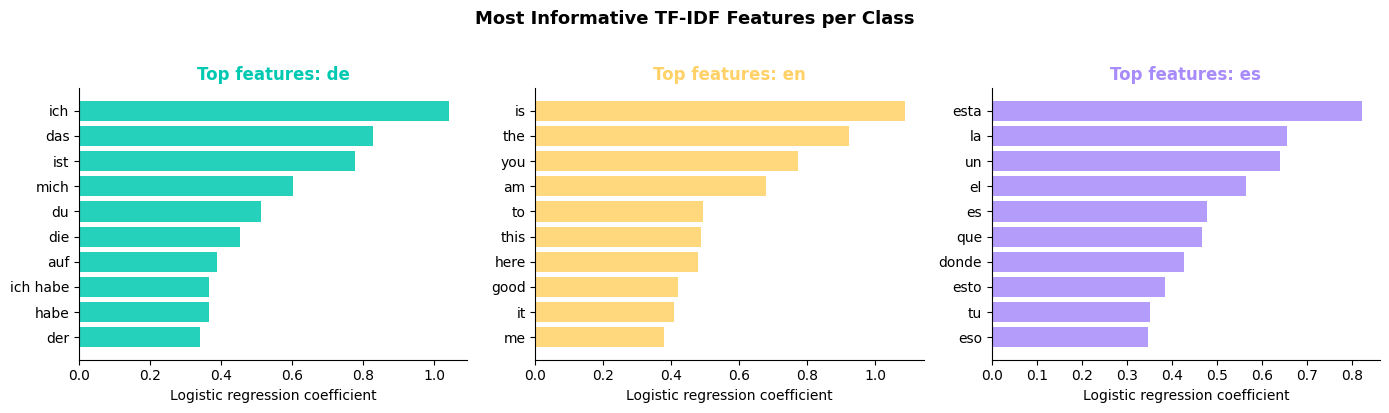

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
classes = clf.classes_
colors  = ["#00C9B1", "#FFD166", "#A78BFA"]

for ax, cls, col in zip(axes, classes, colors):
    # Logistic regression coefficients = feature importance
    cls_idx = list(classes).index(cls)
    coef = clf.coef_[cls_idx]
    top_idx = coef.argsort()[-10:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    top_scores   = [coef[i] for i in top_idx]

    ax.barh(range(10), top_scores[::-1], color=col, alpha=0.85)
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_features[::-1], fontsize=10)
    ax.set_title(f"Top features: {cls}", fontweight="bold", color=col)
    ax.set_xlabel("Logistic regression coefficient")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Most Informative TF-IDF Features per Class", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
def predict(text: str) -> None:
    vec = vectorizer.transform([text])
    pred  = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    print(f"Text:  '{text}'")
    print(f"Prediction: {pred}")
    for cls, p in zip(clf.classes_, proba):
        bar = "█" * int(p * 30)
        print(f"  {cls:10s}  {bar:30s}  {p:.2%}")
    print()

predict("Der Himmel ist blau")
predict("The parliament debates a new data privacy legislation")

Text:  'Der Himmel ist blau'
Prediction: de
  de          █████████████                   44.89%
  en          ████████                        27.03%
  es          ████████                        28.08%

Text:  'The parliament debates a new data privacy legislation'
Prediction: en
  de          █████                           16.94%
  en          ███████████████████             65.83%
  es          █████                           17.23%

